# Otsu Preprocessing

In [1]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("dataset")
PROCESS_DIR = DATA_DIR / "process"

In [2]:
def normalize_signature(image):
    gray = np.array(image.convert("L"))
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(binary)


for folder in ["full_org", "full_forg"]:
    source_dir = DATA_DIR / folder
    output_dir = PROCESS_DIR / folder
    output_dir.mkdir(parents=True, exist_ok=True)
    count = 0
    for path in sorted(source_dir.iterdir()):
        if not path.is_file() or path.suffix.lower() not in {".png", ".jpg", ".jpeg", ".bmp"}:
            continue
        with Image.open(path) as image:
            processed = normalize_signature(image)
        processed.save(output_dir / f"{path.stem}.png")
        count += 1
    print(f"{folder}: saved {count} images to {output_dir}")

full_org: saved 1320 images to dataset\process\full_org


full_forg: saved 1320 images to dataset\process\full_forg


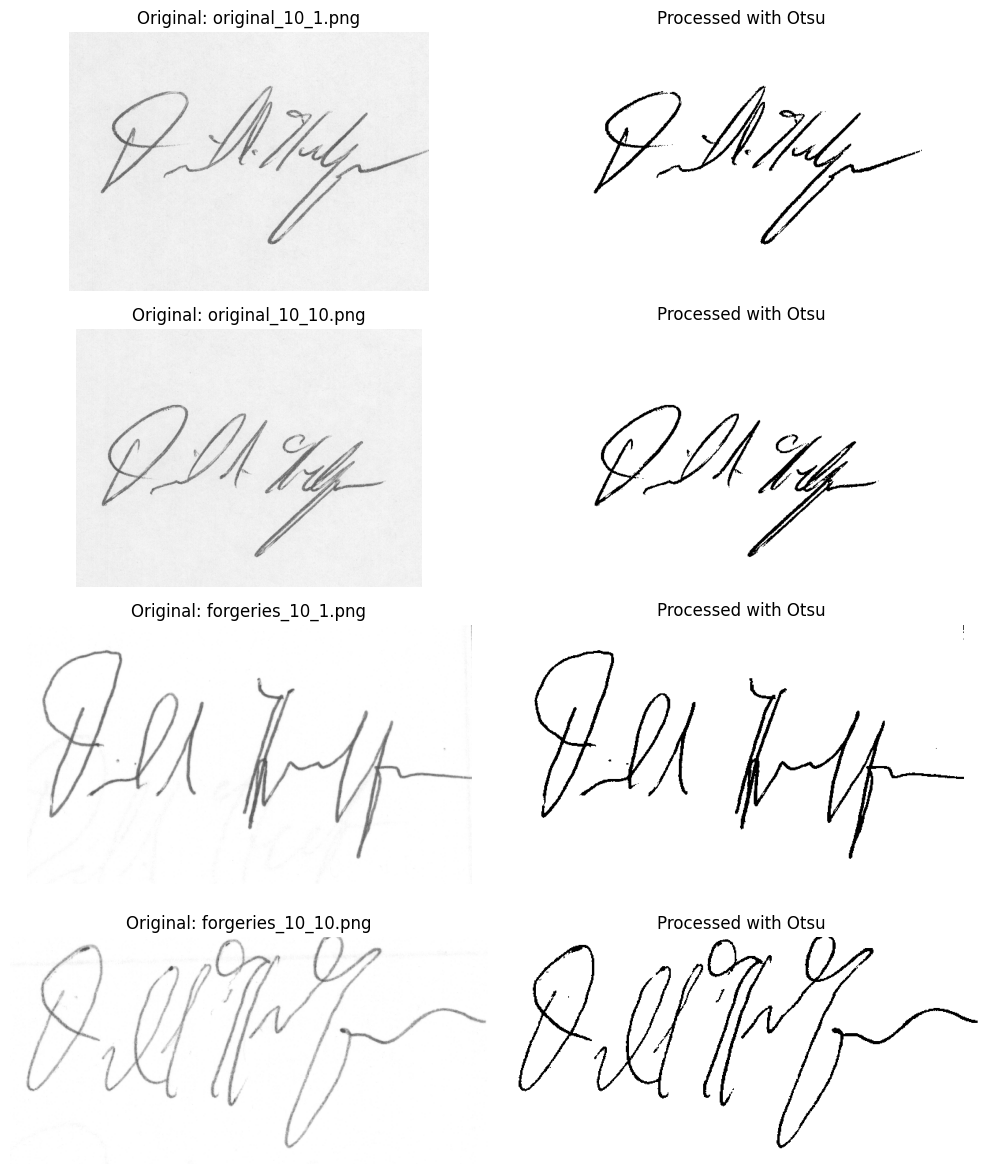

In [3]:
preview_paths = []
for folder in ["full_org", "full_forg"]:
    preview_paths.extend(sorted((DATA_DIR / folder).glob("*.png"))[:2])

fig, axes = plt.subplots(len(preview_paths), 2, figsize=(10, 3 * len(preview_paths)), squeeze=False)
for row, path in enumerate(preview_paths):
    with Image.open(path) as image:
        axes[row, 0].imshow(image.convert("L"), cmap="gray", vmin=0, vmax=255)
    processed_path = PROCESS_DIR / path.parent.name / f"{path.stem}.png"
    with Image.open(processed_path) as image:
        axes[row, 1].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"Original: {path.name}")
    axes[row, 1].set_title("Processed with Otsu")
    for axis in axes[row]:
        axis.axis("off")
plt.tight_layout()
plt.show()